In [1]:
## Import and Load data

import sklearn
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn 
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

random_seeds = 42
torch.manual_seed(random_seeds)
np.random.seed(random_seeds)
if torch.cuda.is_available():
    torch.cuda.manual_seed(random_seeds)
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu") #It seems that for this project CPU is always faster tha gpu
print(device)

df = pd.read_csv("./data/california_housing.csv")
df.head()

cpu


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


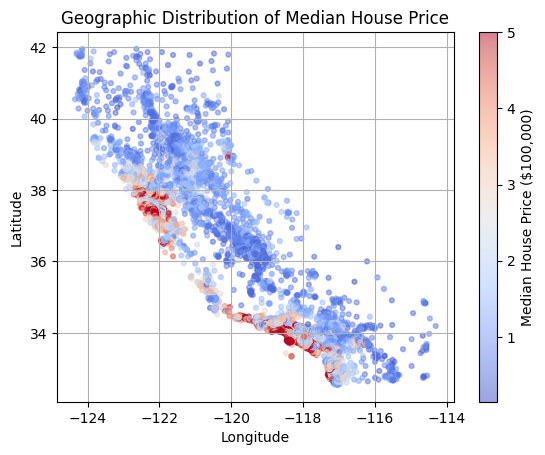

In [16]:
map_plt = plt.scatter(df['Longitude'],df["Latitude"],c=df["MedHouseVal"],cmap="coolwarm",s=12,alpha = 0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Median House Price")
plt.colorbar(map_plt, label = "Median House Price ($100,000)")
plt.grid()

In [35]:
## Ridge Regression 1: with geo info

X=df.drop(columns = ["MedHouseVal"])
y=df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

ridge_model = make_pipeline(
    StandardScaler(),
    Ridge()
)

parameter_grid = {
    "ridge__alpha":[0.01,0.1,1,10,100]
}

ridge_cv = GridSearchCV(
    ridge_model,
    parameter_grid,
    cv = 5,
    scoring = "neg_mean_squared_error",
    return_train_score=True
)

ridge_cv.fit(X_train,y_train)

print("Best alpha:", ridge_cv.best_params_)
print("Best CV MSE:", -ridge_cv.best_score_)

y_pred = ridge_cv.predict(X_test)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

y_train_pred = ridge_cv.predict(X_train)
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Train R2:", r2_score(y_train, y_train_pred))

## Save params for plotting
mse_with_geo = mean_squared_error(y_test, y_pred)
r_2_with_geo = r2_score(y_test, y_pred)

mse_with_geo_train = mean_squared_error(y_train, y_train_pred)
r_2_with_geo_train = r2_score(y_train, y_train_pred)

cvmse_with = -ridge_cv.cv_results_.get("mean_test_score")
cvmse_with

Best alpha: {'ridge__alpha': 0.01}
Best CV MSE: 0.5192652045735378
Test MSE: 0.5558912301037882
Test R2: 0.5757879873121599
Train MSE: 0.5179331255339802
Train R2: 0.6125511913897304


array([0.5192652 , 0.51926524, 0.51926569, 0.51928275, 0.52048295])

In [36]:
## Ridge Regression 2: without geo info

X=df.drop(columns = ["MedHouseVal","Latitude","Longitude"])
y=df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

ridge_model = make_pipeline(
    StandardScaler(),
    Ridge()
)

parameter_grid = {
    "ridge__alpha":[0.01,0.1,1,10,100]
}

ridge_cv = GridSearchCV(
    ridge_model,
    parameter_grid,
    cv = 5,
    scoring = "neg_mean_squared_error"
)

ridge_cv.fit(X_train,y_train)

print("Best alpha:", ridge_cv.best_params_)
print("Best CV MSE:", -ridge_cv.best_score_)

y_pred = ridge_cv.predict(X_test)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

y_train_pred = ridge_cv.predict(X_train)
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Train R2:", r2_score(y_train, y_train_pred))

## Save params for plotting
mse_wout_geo = mean_squared_error(y_test, y_pred)
r_2_wout_geo = r2_score(y_test, y_pred)


mse_wout_geo_train = mean_squared_error(y_train, y_train_pred)
r_2_wout_geo_train = r2_score(y_train, y_train_pred)

cvmse_wout = -ridge_cv.cv_results_.get("mean_test_score")
cvmse_wout

Best alpha: {'ridge__alpha': 10}
Best CV MSE: 0.6116142245576465
Test MSE: 0.6417240346466321
Test R2: 0.5102872116245067
Train MSE: 0.6070146273921984
Train R2: 0.545912237318978


array([0.61166454, 0.61166401, 0.61165876, 0.61161422, 0.61182634])

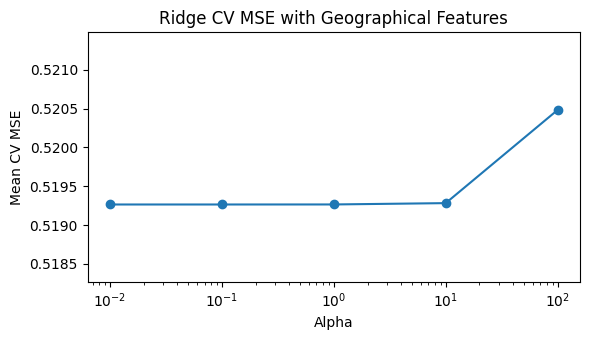

In [40]:
alpha_values = [0.01,0.1,1,10,100]
plt.figure(figsize=(6, 3.5))
plt.plot(alpha_values, MSE_with_geo, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean CV MSE')
plt.title('Ridge CV MSE with Geographical Features')
plt.ylim(min(MSE_with_geo)-0.001, max(MSE_with_geo)+0.001)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 3.5))
plt.plot(alpha_values, MSE_wout_geo, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean CV MSE')
plt.title('Ridge CV MSE without Geographical Features')
plt.ylim(min(MSE_wout_geo)-0.001, max(MSE_wout_geo)+0.001)
plt.tight_layout()
plt.show()

In [ ]:
## NN 1: with geo info

X = df.drop(columns = ["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

class HousingNN(nn.Module):
    def __init__(self,input_dim,hidden1=64,hidden2=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1,hidden2),
            nn.ReLU(),
            nn.Linear(hidden2,1)
        )
    
    def forward(self,x):
        return self.net(x)
        
def train_nn(X_train_np,y_train_np,X_val_np,y_val_np,
             hidden1 = 64, hidden2 = 32,
             lr = 0.001, epochs = 100, batch_size = 64):
    device = torch.device("cpu")
    
    X_train_tensor = torch.tensor(X_train_np,dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np,dtype=torch.float32).view(-1, 1)
    
    X_val_tensor = torch.tensor(X_val_np,dtype=torch.float32).to(device)
    
    train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
    train_loader = DataLoader(train_dataset,batch_size = batch_size, shuffle=True)
    
    model = HousingNN(
        input_dim=X_train_np.shape[1],
        hidden1=hidden1,
        hidden2=hidden2
    ).to(device)
    
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=lr)
    
    for epoch in range(epochs):
        model.train()
        
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            y_pred = model(batch_X)
            loss = loss_fn(y_pred,batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor).cpu().numpy().reshape(-1)
        
    val_mse = mean_squared_error(y_val_np,val_pred)
    
    return model, val_mse

hidden_size_options = [
    (16,8),
    (32,16),
    (64,32),
    (128,64),
]

kf = KFold(n_splits=5,shuffle=True,random_state=42)

cv_results = []
X_train_df = X_train.reset_index(drop = True)
y_train_series = y_train.reset_index(drop = True)

for hidden1, hidden2 in hidden_size_options:
    fold_mses = []
    
    for train_idx, val_idx in kf.split(X_train_df):
        X_fold_train = X_train_df.iloc[train_idx]
        X_fold_val = X_train_df.iloc[val_idx]
        y_fold_train = y_train_series.iloc[train_idx]
        y_fold_val = y_train_series.iloc[val_idx]
        
        scalar = StandardScaler()
        X_fold_train_scaled = scalar.fit_transform(X_fold_train)
        X_fold_val_scaled = scalar.transform(X_fold_val)
        
        _, val_mse = train_nn(
            X_fold_train_scaled,
            y_fold_train.to_numpy(),
            X_fold_val_scaled,
            y_fold_val.to_numpy(),
            hidden1=hidden1,
            hidden2=hidden2,
            lr = 0.001,
            epochs=100,
            batch_size=64
        )
        
        fold_mses.append(val_mse)
        
        
    mean_cv_mse = np.mean(fold_mses)
    
    cv_results.append({
        "hidden1": hidden1,
        "hidden2": hidden2,
        "CV MSE": mean_cv_mse
    })

    print(f"Hidden sizes ({hidden1}, {hidden2}) - CV MSE: {mean_cv_mse:.4f}")
    
cv_results_df = pd.DataFrame(cv_results)
print("\nCross-validation results:")
print(cv_results_df)

best_row = cv_results_df.loc[cv_results_df["CV MSE"].idxmin()]
best_hidden1 = int(best_row["hidden1"])
best_hidden2 = int(best_row["hidden2"])

print("\nBest hidden sizes:", (best_hidden1, best_hidden2))

final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train)
X_test_scaled = final_scaler.transform(X_test)

final_model, _ = train_nn(
    X_train_scaled,
    y_train.to_numpy(),
    X_test_scaled,
    y_test.to_numpy(),
    hidden1=best_hidden1,
    hidden2=best_hidden2,
    lr=0.001,
    epochs=200,
    batch_size=64
)

final_model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    y_pred = final_model(X_test_tensor).cpu().numpy().reshape(-1)

print("\nFinal PyTorch NN Test Results:")
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

## Save params for plotting
nn_mse_with_geo = mean_squared_error(y_test, y_pred)
nn_r_2_with_geo = r2_score(y_test, y_pred)
nn_cv_results_with_geo = cv_results

with torch.no_grad():
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_pred = final_model(X_train_tensor).cpu().numpy().reshape(-1)
    
nn_mse_with_geo_train = mean_squared_error(y_train, y_train_pred)
nn_r_2_with_geo_train = r2_score(y_train, y_train_pred)

Hidden sizes (16, 8) - CV MSE: 0.3008
Hidden sizes (32, 16) - CV MSE: 0.2885
Hidden sizes (64, 32) - CV MSE: 0.2772
Hidden sizes (128, 64) - CV MSE: 0.2791

Cross-validation results:
   hidden1  hidden2    CV MSE
0       16        8  0.300804
1       32       16  0.288472
2       64       32  0.277247
3      128       64  0.279144

Best hidden sizes: (64, 32)


In [ ]:
## NN 2 without geo info

X = df.drop(columns = ["Latitude" , "Longitude",  "MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

class HousingNN(nn.Module):
    def __init__(self,input_dim,hidden1=64,hidden2=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1,hidden2),
            nn.ReLU(),
            nn.Linear(hidden2,1)
        )
    
    def forward(self,x):
        return self.net(x)
        
def train_nn(X_train_np,y_train_np,X_val_np,y_val_np,
             hidden1 = 64, hidden2 = 32,
             lr = 0.001, epochs = 100, batch_size = 64):
    device = torch.device("cpu")
    
    X_train_tensor = torch.tensor(X_train_np,dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np,dtype=torch.float32).view(-1, 1)
    
    X_val_tensor = torch.tensor(X_val_np,dtype=torch.float32).to(device)
    
    train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
    train_loader = DataLoader(train_dataset,batch_size = batch_size, shuffle=True)
    
    model = HousingNN(
        input_dim=X_train_np.shape[1],
        hidden1=hidden1,
        hidden2=hidden2
    ).to(device)
    
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=lr)
    
    for epoch in range(epochs):
        model.train()
        
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            y_pred = model(batch_X)
            loss = loss_fn(y_pred,batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor).cpu().numpy().reshape(-1)
        
    val_mse = mean_squared_error(y_val_np,val_pred)
    
    return model, val_mse

hidden_size_options = [
    (16,8),
    (32,16),
    (64,32),
    (128,64),
]

kf = KFold(n_splits=5,shuffle=True,random_state=42)

cv_results = []
X_train_df = X_train.reset_index(drop = True)
y_train_series = y_train.reset_index(drop = True)

for hidden1, hidden2 in hidden_size_options:
    fold_mses = []
    
    for train_idx, val_idx in kf.split(X_train_df):
        X_fold_train = X_train_df.iloc[train_idx]
        X_fold_val = X_train_df.iloc[val_idx]
        y_fold_train = y_train_series.iloc[train_idx]
        y_fold_val = y_train_series.iloc[val_idx]
        
        scalar = StandardScaler()
        X_fold_train_scaled = scalar.fit_transform(X_fold_train)
        X_fold_val_scaled = scalar.transform(X_fold_val)
        
        _, val_mse = train_nn(
            X_fold_train_scaled,
            y_fold_train.to_numpy(),
            X_fold_val_scaled,
            y_fold_val.to_numpy(),
            hidden1=hidden1,
            hidden2=hidden2,
            lr = 0.001,
            epochs=100,
            batch_size=64
        )
        
        fold_mses.append(val_mse)
        
        
    mean_cv_mse = np.mean(fold_mses)
    
    cv_results.append({
        "hidden1": hidden1,
        "hidden2": hidden2,
        "CV MSE": mean_cv_mse
    })

    print(f"Hidden sizes ({hidden1}, {hidden2}) - CV MSE: {mean_cv_mse:.4f}")
    
cv_results_df = pd.DataFrame(cv_results)
print("\nCross-validation results:")
print(cv_results_df)

best_row = cv_results_df.loc[cv_results_df["CV MSE"].idxmin()]
best_hidden1 = int(best_row["hidden1"])
best_hidden2 = int(best_row["hidden2"])

print("\nBest hidden sizes:", (best_hidden1, best_hidden2))

final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train)
X_test_scaled = final_scaler.transform(X_test)

final_model, _ = train_nn(
    X_train_scaled,
    y_train.to_numpy(),
    X_test_scaled,
    y_test.to_numpy(),
    hidden1=best_hidden1,
    hidden2=best_hidden2,
    lr=0.001,
    epochs=200,
    batch_size=64
)

final_model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    y_pred = final_model(X_test_tensor).cpu().numpy().reshape(-1)

print("\nFinal PyTorch NN Test Results:")
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

## Save params for plotting
nn_mse_wout_geo = mean_squared_error(y_test, y_pred)
nn_r_2_wout_geo = r2_score(y_test, y_pred)
nn_cv_results_wout_geo = cv_results

with torch.no_grad():
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_pred = final_model(X_train_tensor).cpu().numpy().reshape(-1)
    
nn_mse_wout_geo_train = mean_squared_error(y_train, y_train_pred)
nn_r_2_wout_geo_train = r2_score(y_train, y_train_pred)

Hidden sizes (16, 8) - CV MSE: 0.4115
Hidden sizes (32, 16) - CV MSE: 0.4057
Hidden sizes (64, 32) - CV MSE: 0.4021
Hidden sizes (128, 64) - CV MSE: 0.4014

Cross-validation results:
   hidden1  hidden2    CV MSE
0       16        8  0.411544
1       32       16  0.405748
2       64       32  0.402096
3      128       64  0.401419

Best hidden sizes: (128, 64)

Final PyTorch NN Test Results:
Test MSE: 0.42709528185148643
Test MAE: 0.45616619359280247
Test R2: 0.6740748201948208


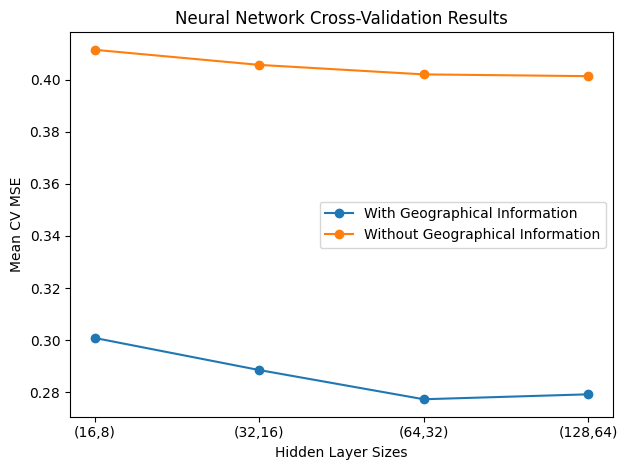

In [ ]:
layer_nums = ['(16,8)','(32,16)','(64,32)','(128,64)']
MSE_with_geo = [x.get('CV MSE') for x in nn_cv_results_with_geo]
MSE_wout_geo = [x.get('CV MSE') for x in nn_cv_results_wout_geo]
plt.plot(
    layer_nums,
    MSE_with_geo,
    marker="o",
    label = "With Geographical Information"
)
plt.plot(
    layer_nums,
    MSE_wout_geo,
    marker="o",
    label = "Without Geographical Information"
)
plt.xlabel("Hidden Layer Sizes")
plt.ylabel("Mean CV MSE")
plt.title("Neural Network Cross-Validation Results")
plt.legend()
plt.tight_layout()
plt.show()

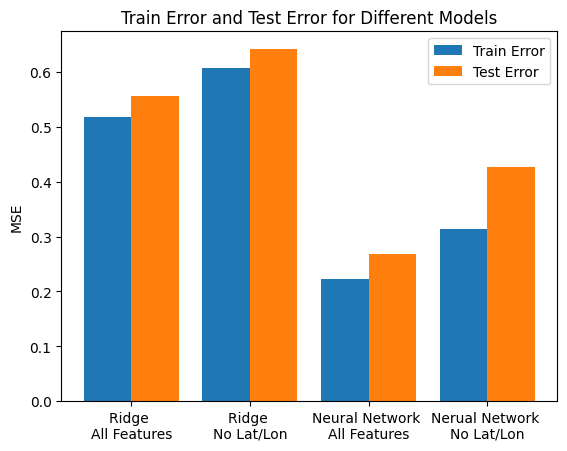

In [ ]:
train_errors = [mse_with_geo_train,mse_wout_geo_train,nn_mse_with_geo_train,nn_mse_wout_geo_train]
test_errors = [mse_with_geo,mse_wout_geo,nn_mse_with_geo,nn_mse_wout_geo]
models = ['Ridge \nAll Features', 
          'Ridge \nNo Lat/Lon',
          'Neural Network \nAll Features',
          'Nerual Network \nNo Lat/Lon']
w, x = 0.4, np.arange(len(models))

plt.bar(x - w/2, train_errors, w, label='Train Error')
plt.bar(x + w/2, test_errors, w, label='Test Error')
plt.xticks(x, models)
plt.ylabel('MSE')
plt.title('Train Error and Test Error for Different Models')
plt.legend()
plt.show()

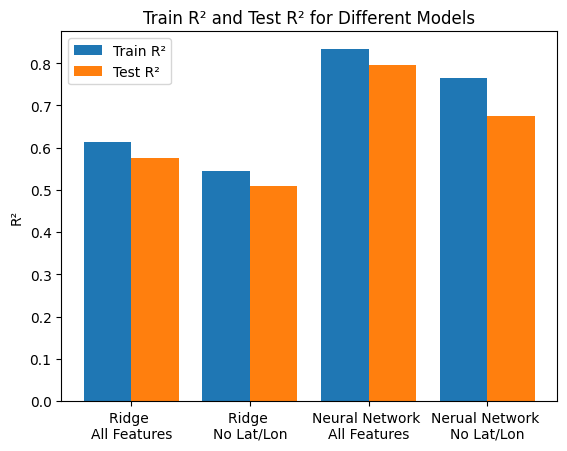

In [ ]:
r_2_test = [r_2_with_geo,r_2_wout_geo,nn_r_2_with_geo,nn_r_2_wout_geo]
r_2_train = [r_2_with_geo_train,r_2_wout_geo_train,nn_r_2_with_geo_train,nn_r_2_wout_geo_train]
models = ['Ridge \nAll Features', 
          'Ridge \nNo Lat/Lon',
          'Neural Network \nAll Features',
          'Nerual Network \nNo Lat/Lon']
w, x = 0.4, np.arange(len(models))

plt.bar(x - w/2, r_2_train, w, label='Train R²')
plt.bar(x + w/2, r_2_test, w, label='Test R²')
plt.xticks(x, models)
plt.ylabel('R²')
plt.title('Train R² and Test R² for Different Models')
plt.legend()
plt.show()